# Comportamiento de Usuarios de Empresa Alimenticia

## Paso 1. Abrir el archivo de datos y leer la información general

In [1]:

import pandas as pd

# Carga del archivo (Separado por tabulaciones)
df = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

# Vista general
print("\nPrimeras 5 filas:")
display(df.head())

print("\nInformación general (tipos y nulos):")
df.info()

print("\nNulos por columna:")
print(df.isna().sum())

print("\nValores únicos:")
print("Eventos únicos:", df['EventName'].nunique())
print("Usuarios únicos:", df['DeviceIDHash'].nunique())

print("\nTamaño (filas, columnas):", df.shape)

print("\nDistribución por grupo (ExpId):")
print(df['ExpId'].value_counts())


Primeras 5 filas:


,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248



Información general (tipos y nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB

Nulos por columna:
EventName         0
DeviceIDHash      0
EventTimestamp    0
ExpId             0
dtype: int64

Valores únicos:
Eventos únicos: 5
Usuarios únicos: 7551

Tamaño (filas, columnas): (244126, 4)

Distribución por grupo (ExpId):
248    85747
246    80304
247    78075
Name: ExpId, dtype: int64


## Paso 2. Preparar los datos para el análisis

In [2]:
# Renombrar columnas a un formato más cómodo
df = df.rename(columns={
    'EventName': 'event_name',
    'DeviceIDHash': 'user_id',
    'EventTimestamp': 'event_timestamp',
    'ExpId': 'exp_id'
})

# Verificar cambio
print(df.columns.tolist())
df.head()

['event_name', 'user_id', 'event_timestamp', 'exp_id']


,event_name,user_id,event_timestamp,exp_id
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [3]:
# Revisar tipos de datos
df.info()

print("\nValores ausentes por columna:")
print(df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   event_name       244126 non-null  object
 1   user_id          244126 non-null  int64 
 2   event_timestamp  244126 non-null  int64 
 3   exp_id           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB

Valores ausentes por columna:
event_name         0
user_id            0
event_timestamp    0
exp_id             0
dtype: int64


In [4]:
# Convertir timestamp a datetime
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'], unit='s')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       244126 non-null  object        
 1   user_id          244126 non-null  int64         
 2   event_timestamp  244126 non-null  datetime64[ns]
 3   exp_id           244126 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 7.5+ MB


Los tipos de datos fueron revisados. La columna event_timestamp se convirtió a formato datetime para facilitar el análisis temporal. No se detectaron valores ausentes relevantes, por lo que no fue necesario realizar imputaciones ni eliminaciones adicionales.

In [5]:
# Columna de fecha y hora
df['event_datetime'] = df['event_timestamp']

# Columna solo con la fecha
df['event_date'] = df['event_datetime'].dt.date

# Verificar resultado
df[['event_datetime', 'event_date']].head()


,event_datetime,event_date
0,2019-07-25 04:43:36,2019-07-25
1,2019-07-25 11:11:42,2019-07-25
2,2019-07-25 11:28:47,2019-07-25
3,2019-07-25 11:28:47,2019-07-25
4,2019-07-25 11:48:42,2019-07-25


## Paso 3. Estudiar y comprobar los datos

In [6]:

# Cantidad total de eventos
total_events = df.shape[0]
print("Cantidad total de eventos:", total_events)


Cantidad total de eventos: 244126


In [7]:

# Cantidad de usuarios únicos
total_users = df['user_id'].nunique()
print("Cantidad total de usuarios:", total_users)


Cantidad total de usuarios: 7551


In [8]:
# Eventos por usuario
events_per_user = df.groupby('user_id').size()

# Promedio de eventos por usuario
avg_events_per_user = events_per_user.mean()

print("Promedio de eventos por usuario:", round(avg_events_per_user, 2))


Promedio de eventos por usuario: 32.33


In [9]:
## ¿Qué periodo de tiempo cubren los datos?

# Fechas mínima y máxima
min_date = df['event_datetime'].min()
max_date = df['event_datetime'].max()

print("Fecha mínima:", min_date)
print("Fecha máxima:", max_date)


Fecha mínima: 2019-07-25 04:43:36
Fecha máxima: 2019-08-07 21:15:17


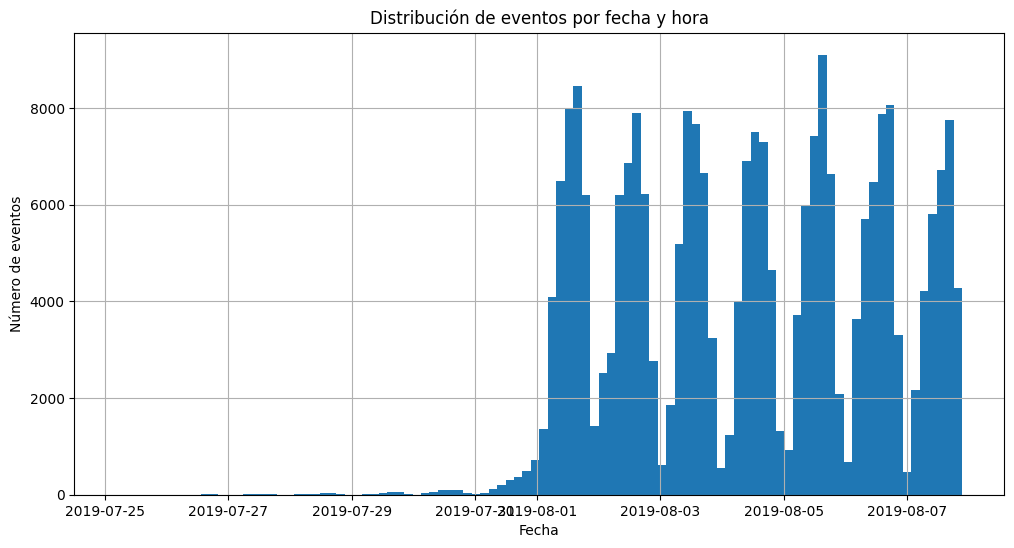

In [10]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df['event_datetime'].hist(bins=100)
plt.title('Distribución de eventos por fecha y hora')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.show()


In [11]:

# Eventos por día
events_per_day = (
    df.groupby('event_date')
    .size()
    .reset_index(name='events_count')
)

events_per_day.head()



,event_date,events_count
0,2019-07-25,9
1,2019-07-26,31
2,2019-07-27,55
3,2019-07-28,105
4,2019-07-29,184


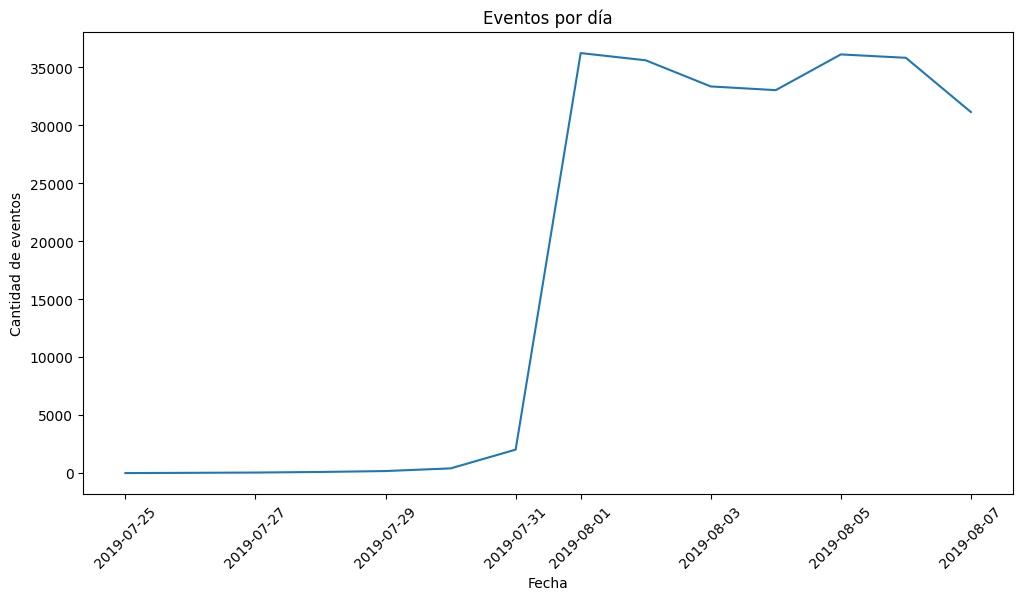

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(events_per_day['event_date'], events_per_day['events_count'])
plt.title('Eventos por día')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de eventos')
plt.xticks(rotation=45)
plt.show()


A partir del análisis de la cantidad de eventos por día, se observa que los datos comienzan a ser estables desde el 01/08/2019. Antes de esa fecha, el volumen de eventos es significativamente menor, lo que sugiere registros incompletos. Por esta razón, el análisis posterior se realiza únicamente a partir del 01/08/2019.

In [13]:
# Definir fecha de inicio con datos completos (AJUSTA según tu gráfico)
start_date = pd.to_datetime('2019-08-01')

# Filtrar dataset
df = df[df['event_datetime'] >= start_date].reset_index(drop=True)


In [14]:
print("Nuevo periodo de análisis:")
print("Desde:", df['event_datetime'].min())
print("Hasta:", df['event_datetime'].max())

print("\nEventos restantes:", df.shape[0])
print("Usuarios restantes:", df['user_id'].nunique())


Nuevo periodo de análisis:
Desde: 2019-08-01 00:07:28
Hasta: 2019-08-07 21:15:17

Eventos restantes: 241298
Usuarios restantes: 7534


In [15]:
df_full = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

# Renombrar columnas (igual que antes)
df_full = df_full.rename(columns={
    'EventName': 'event_name',
    'DeviceIDHash': 'user_id',
    'EventTimestamp': 'event_timestamp',
    'ExpId': 'exp_id'
})

df_full['event_datetime'] = pd.to_datetime(df_full['event_timestamp'], unit='s')



In [16]:
events_before = df_full.shape[0]
users_before = df_full['user_id'].nunique()

events_after = df.shape[0]
users_after = df['user_id'].nunique()

print("Eventos antes:", events_before)
print("Eventos después:", events_after)
print("Diferencia:", events_before - events_after)
print("Usuarios antes:", users_before)
print("Usuarios después:", users_after)
print("Diferencia:", users_before - users_after)

Eventos antes: 244126
Eventos después: 241298
Diferencia: 2828
Usuarios antes: 7551
Usuarios después: 7534
Diferencia: 17


Tras excluir los datos anteriores al 01/08/2019, se observa una reducción limitada en el número total de eventos y usuarios. La pérdida no es significativa y corresponde principalmente a registros incompletos del período inicial, por lo que el filtrado mejora la calidad del análisis sin afectar de forma sustancial la muestra.

In [17]:
# Usuarios únicos por grupo experimental
users_by_group = (
    df.groupby('exp_id')['user_id']
    .nunique()
    .reset_index(name='users_count')
)

users_by_group


,exp_id,users_count
0,246,2484
1,247,2513
2,248,2537


Tras el filtrado del período de datos, se confirma que el dataset sigue incluyendo usuarios de los tres grupos experimentales (246, 247 y 248). Por lo tanto, el conjunto de datos es adecuado para continuar con el análisis del experimento A/A/B.

# Paso 4. Estudiar el embudo de eventos

In [18]:
# Frecuencia de cada evento
event_frequency = (
    df['event_name']
    .value_counts()
    .reset_index()
)

event_frequency.columns = ['event_name', 'events_count']

event_frequency


,event_name,events_count
0,MainScreenAppear,117431
1,OffersScreenAppear,46350
2,CartScreenAppear,42365
3,PaymentScreenSuccessful,34113
4,Tutorial,1039


In [19]:
# Total de usuarios
total_users = df['user_id'].nunique()

# Usuarios únicos por evento
users_per_event = (
    df.groupby('event_name')['user_id']
    .nunique()
    .reset_index(name='users_count')
)

# Proporción de usuarios que realizaron el evento
users_per_event['users_share'] = users_per_event['users_count'] / total_users

# Ordenar por cantidad de usuarios
users_per_event = users_per_event.sort_values(
    by='users_count', ascending=False
)

users_per_event


,event_name,users_count,users_share
1,MainScreenAppear,7419,0.984736
2,OffersScreenAppear,4593,0.609636
0,CartScreenAppear,3734,0.495620
3,PaymentScreenSuccessful,3539,0.469737
4,Tutorial,840,0.111495


La mayor parte de los usuarios interactúa con las pantallas iniciales de la aplicación. A medida que avanzan por el embudo, la cantidad de usuarios disminuye progresivamente, siendo el evento de pago el que presenta la menor proporción de usuarios.

Las acciones principales de los usuarios siguen una secuencia lógica desde la apertura de la aplicación hasta la finalización del pago. El evento Tutorial no forma parte del proceso de compra, ya que es opcional y puede ocurrir en distintos momentos, por lo que no se incluye en el cálculo del embudo.

In [20]:
funnel_events = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]


In [21]:
funnel_users = (
    df[df['event_name'].isin(funnel_events)]
    .groupby('event_name')['user_id']
    .nunique()
    .reindex(funnel_events)
)

funnel_users


event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Name: user_id, dtype: int64

In [22]:
funnel_df = funnel_users.reset_index()
funnel_df.columns = ['event_name', 'users_count']

# Proporción respecto a la etapa anterior
funnel_df['conversion_from_previous'] = (
    funnel_df['users_count'] / funnel_df['users_count'].shift(1)
)

funnel_df


,event_name,users_count,conversion_from_previous
0,MainScreenAppear,7419,NaN
1,OffersScreenAppear,4593,0.619086
2,CartScreenAppear,3734,0.812976
3,PaymentScreenSuccessful,3539,0.947777


El embudo de conversión muestra una disminución progresiva en el número de usuarios a medida que avanzan por las distintas etapas. La proporción de usuarios que pasan de una etapa a la siguiente permite identificar en qué puntos del proceso se produce la mayor pérdida de usuarios.

In [23]:
# Pérdida absoluta de usuarios entre etapas
funnel_df['users_lost'] = (
    funnel_df['users_count'].shift(1) - funnel_df['users_count']
)

funnel_df


,event_name,users_count,conversion_from_previous,users_lost
0,MainScreenAppear,7419,NaN,NaN
1,OffersScreenAppear,4593,0.619086,2826.0
2,CartScreenAppear,3734,0.812976,859.0
3,PaymentScreenSuccessful,3539,0.947777,195.0


In [24]:
max_loss_stage = funnel_df.loc[
    funnel_df['users_lost'].idxmax()
]

print("Mayor pérdida de usuarios ocurre en:")
print(max_loss_stage[['event_name', 'users_lost']])


Mayor pérdida de usuarios ocurre en:
event_name    OffersScreenAppear
users_lost                2826.0
Name: 1, dtype: object


La mayor parte de los usuarios abandona el proceso en "Offers Screen".

In [25]:
# Usuarios que iniciaron el embudo
users_start = funnel_df.loc[
    funnel_df['event_name'] == 'MainScreenAppear',
    'users_count'
].values[0]

# Usuarios que completaron el pago
users_paid = funnel_df.loc[
    funnel_df['event_name'] == 'PaymentScreenSuccessful',
    'users_count'
].values[0]

# Porcentaje de conversión total
total_conversion_pct = users_paid / users_start * 100

print(f"Porcentaje de usuarios que completan todo el embudo: {total_conversion_pct:.2f}%")


Porcentaje de usuarios que completan todo el embudo: 47.70%


Aproximadamente 48% de los usuarios que inician el uso de la aplicación completan todo el proceso de compra hasta el pago.

# Paso 5. Estudiar los resultados del experimento

In [26]:
# Usuarios únicos por grupo experimental
users_by_group = (
    df.groupby('exp_id')['user_id']
    .nunique()
    .reset_index(name='users_count')
)

users_by_group


,exp_id,users_count
0,246,2484
1,247,2513
2,248,2537


Los usuarios se distribuyen entre los tres grupos experimentales de forma relativamente uniforme. Esto indica que la asignación a los grupos fue adecuada y permite comparar los resultados del experimento sin sesgos evidentes en el tamaño de las muestras.

In [27]:
# Evento más popular por número de usuarios
top_event = (
    df.groupby('event_name')['user_id']
    .nunique()
    .idxmax()
)

top_event


'MainScreenAppear'

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Usuarios totales por grupo
users_246 = df[df['exp_id'] == 246]['user_id'].nunique()
users_247 = df[df['exp_id'] == 247]['user_id'].nunique()

# Usuarios que realizaron el evento en cada grupo
event_246 = df[
    (df['exp_id'] == 246) & (df['event_name'] == top_event)
]['user_id'].nunique()

event_247 = df[
    (df['exp_id'] == 247) & (df['event_name'] == top_event)
]['user_id'].nunique()

# Test de proporciones
stat, pvalue = proportions_ztest(
    [event_246, event_247],
    [users_246, users_247]
)

print(f"Evento analizado: {top_event}")
print(f"p-value: {pvalue}")


In [ ]:
alpha = 0.05

if pvalue < alpha:
    print("Se detecta una diferencia estadísticamente significativa")
else:
    print("No se detecta una diferencia estadísticamente significativa")


Para validar el experimento, se compararon los dos grupos de control (246 y 247) mediante un test de proporciones aplicado al evento más frecuente. No se detectaron diferencias estadísticamente significativas entre ambos grupos (p-value > 0.05), lo que confirma que los grupos de control son comparables y que el experimento está correctamente configurado.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

def aa_test_for_event(df, event_name, group_a=246, group_b=247, alpha=0.05):
    """
    Realiza un test de proporciones entre dos grupos para un evento dado.
    """
    # Usuarios totales por grupo
    users_a = df[df['exp_id'] == group_a]['user_id'].nunique()
    users_b = df[df['exp_id'] == group_b]['user_id'].nunique()

    # Usuarios que realizaron el evento
    event_a = df[
        (df['exp_id'] == group_a) & (df['event_name'] == event_name)
    ]['user_id'].nunique()

    event_b = df[
        (df['exp_id'] == group_b) & (df['event_name'] == event_name)
    ]['user_id'].nunique()

    # Proporciones
    prop_a = event_a / users_a
    prop_b = event_b / users_b

    # Test estadístico
    stat, pvalue = proportions_ztest(
        [event_a, event_b],
        [users_a, users_b]
    )

    return {
        'event_name': event_name,
        'users_246': event_a,
        'users_247': event_b,
        'prop_246': prop_a,
        'prop_247': prop_b,
        'p_value': pvalue,
        'significant': pvalue < alpha
    }


In [ ]:
# Lista de eventos
events = df['event_name'].unique()

# Ejecutar test A/A para cada evento
aa_results = []

for event in events:
    result = aa_test_for_event(df, event)
    aa_results.append(result)

aa_results_df = pd.DataFrame(aa_results)
aa_results_df


Se compararon los grupos de control 246 y 247 para todos los eventos mediante pruebas de proporciones. En ninguno de los casos se detectaron diferencias estadísticamente significativas (p-value > 0.05). Las proporciones de usuarios que realizaron cada evento son muy similares entre ambos grupos, lo que confirma que los grupos de control fueron divididos correctamente y que el experimento A/A está bien configurado.

In [ ]:
def ab_test_for_event(df, event_name, group_a, group_b, alpha=0.05):
    from statsmodels.stats.proportion import proportions_ztest

    users_a = df[df['exp_id'] == group_a]['user_id'].nunique()
    users_b = df[df['exp_id'] == group_b]['user_id'].nunique()

    event_a = df[
        (df['exp_id'] == group_a) & (df['event_name'] == event_name)
    ]['user_id'].nunique()

    event_b = df[
        (df['exp_id'] == group_b) & (df['event_name'] == event_name)
    ]['user_id'].nunique()

    prop_a = event_a / users_a
    prop_b = event_b / users_b

    stat, pvalue = proportions_ztest(
        [event_a, event_b],
        [users_a, users_b]
    )

    return {
        'event_name': event_name,
        'group_a': group_a,
        'group_b': group_b,
        'prop_a': prop_a,
        'prop_b': prop_b,
        'p_value': pvalue,
        'significant': pvalue < alpha
    }


In [ ]:
events = df['event_name'].unique()

results_248_vs_246 = []
results_248_vs_247 = []

for event in events:
    results_248_vs_246.append(
        ab_test_for_event(df, event, 248, 246)
    )
    results_248_vs_247.append(
        ab_test_for_event(df, event, 248, 247)
    )

df_248_246 = pd.DataFrame(results_248_vs_246)
df_248_247 = pd.DataFrame(results_248_vs_247)

df_248_246, df_248_247


In [ ]:
# Crear dataset con controles combinados
df_control = df[df['exp_id'].isin([246, 247])]
df_test = df[df['exp_id'] == 248]


In [ ]:
def ab_test_combined_control(df_control, df_test, event_name, alpha=0.05):
    from statsmodels.stats.proportion import proportions_ztest

    users_control = df_control['user_id'].nunique()
    users_test = df_test['user_id'].nunique()

    event_control = df_control[
        df_control['event_name'] == event_name
    ]['user_id'].nunique()

    event_test = df_test[
        df_test['event_name'] == event_name
    ]['user_id'].nunique()

    prop_control = event_control / users_control
    prop_test = event_test / users_test

    stat, pvalue = proportions_ztest(
        [event_control, event_test],
        [users_control, users_test]
    )

    return {
        'event_name': event_name,
        'prop_control': prop_control,
        'prop_248': prop_test,
        'p_value': pvalue,
        'significant': pvalue < alpha
    }


In [ ]:
combined_results = []

for event in events:
    combined_results.append(
        ab_test_combined_control(df_control, df_test, event)
    )

combined_results_df = pd.DataFrame(combined_results)
combined_results_df.sort_values('p_value')


Al comparar el grupo experimental (248) con los grupos de control, tanto de forma individual como combinada, no se identificaron diferencias estadísticamente significativas en ninguno de los eventos analizados (p-value > 0.05). Las proporciones de usuarios que realizaron cada acción son muy similares entre los grupos. Por lo tanto, no existe evidencia suficiente para afirmar que el cambio de fuentes tenga un impacto significativo en la experiencia o en la conversión de los usuarios.

En el análisis se utilizó un nivel de significancia de 0.05. En total se realizaron 20 pruebas de hipótesis, considerando los distintos eventos y comparaciones entre grupos. Utilizar un nivel de significancia de 0.1 aumentaría el riesgo de falsos positivos, especialmente al realizar múltiples pruebas. Por esta razón, se considera más adecuado mantener α = 0.05. Incluso aplicando una corrección más estricta por múltiples comparaciones, las conclusiones del experimento no cambian, ya que no se detectaron diferencias estadísticamente significativas entre los grupos.